In [1]:
import argparse
import numpy as np
import torch
from torchvision import datasets
from torch import nn, optim, autograd
import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import Image
from copy import deepcopy
import random
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sam import SAM
from bypass_bn import disable_running_stats, enable_running_stats

In [2]:
parser = argparse.ArgumentParser(description='Heterogeneous-CMNIST')
parser.add_argument('--hidden_dim', type=int, default=512)
parser.add_argument('--wd', type=float,default=0.1) 
parser.add_argument('--lr', type=float, default=0.001)
parser.add_argument('--epoch', type=int, default=20)
parser.add_argument('--seed', type=int, default=0)
parser.add_argument('--batch_size', type=int, default=128)
parser.add_argument('--p', type=float, default=0.95)
flags = parser.parse_args(args=[])

def imshow(image):
    trans = T.ToPILImage(mode='RGB')
    test = trans(image)
    plt.imshow(test)
    
def reset_torch_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    random.seed(seed)
    np.random.seed(seed)

In [3]:
print('Flags:')
for k,v in sorted(vars(flags).items()):
  print("\t{}: {}".format(k, v))

reset_torch_seed(flags.seed)

# Load MNIST, make train/val splits, and shuffle train set examples

mnist = datasets.MNIST('~/datasets/mnist', train=True, download=True)
mnist_train = (mnist.data[:45000], mnist.targets[:45000])
mnist_val_ = (mnist.data[45000:50000], mnist.targets[45000:50000])
mnist_val = (mnist.data[50000:], mnist.targets[50000:])

rng_state = np.random.get_state()
np.random.shuffle(mnist_train[0].numpy())
np.random.set_state(rng_state)
np.random.shuffle(mnist_train[1].numpy())

# Train
train = mnist_train[0]/255
train = torch.stack([train, train, train], dim=1)
target = mnist_train[1]

# GrayScale Train
train_gray = mnist_train[0]/255
train_gray = torch.stack([train_gray, train_gray, train_gray], dim=1)
train_gray_target = mnist_train[1]

for idx, i in enumerate(target):
    if i>=5:
        target[idx] = 1
        train_gray_target[idx]=1
    else:
        target[idx] = 0
        train_gray_target[idx] =0

# In-distribution Val
val = mnist_val_[0]/255
val = torch.stack([val, val, val], dim=1)
val_target = mnist_val_[1]

val_gray = mnist_val_[0]/255
val_gray = torch.stack([val_gray, val_gray, val_gray], dim=1)
val_gray_target = mnist_val_[1]

for idx, i in enumerate(val_target):
    if i>=5:
        val_target[idx] = 1
        val_gray_target[idx] = 1
    else:
        val_target[idx] = 0
        val_gray_target[idx] = 0

        
# Test tot
test_tot = mnist_val[0]/255
test_tot = torch.stack([test_tot, test_tot,test_tot], dim=1)
test_tot_target = mnist_val[1]

# Invariant Test
test_inv = mnist_val[0]/255
test_inv = torch.stack([test_inv, test_inv, test_inv], dim=1)
test_inv_target = mnist_val[1]

# GrayScale Test
test_gray = mnist_val[0]/255
test_gray = torch.stack([test_gray, test_gray, test_gray], dim=1)
test_gray_target = mnist_val[1]

# Spugray Test
test_spugray = mnist_val[0]/255
test_spugray = torch.stack([test_spugray, test_spugray, test_spugray], dim=1)
test_spugray_target = mnist_val[1]
        

Flags:
	batch_size: 128
	epoch: 20
	hidden_dim: 512
	lr: 0.001
	p: 0.95
	seed: 0
	wd: 0.1


In [4]:
# Create Label
for idx, i in enumerate(test_gray_target):
    if i>=5:
        test_gray_target[idx] = 1
        test_inv_target[idx] = 1
        test_tot_target[idx] = 1
        test_spugray_target[idx] = 1
    else:
        test_gray_target[idx] = 0
        test_inv_target[idx] = 0
        test_tot_target[idx] = 0
        test_spugray_target[idx] = 0
test_gray_target

tensor([0, 1, 1,  ..., 1, 1, 1])

In [5]:
# Color Table
red = torch.tensor([125, 0, 0])/255
orange = torch.tensor([255, 165, 0])/255
yellow = torch.tensor([255, 255, 0])/255
pink = torch.tensor([255, 192, 203])/255
magenta = torch.tensor([255, 0, 255])/255

blue = torch.tensor([0, 0, 125])/255
cyan = torch.tensor([0, 255, 255])/255
green = torch.tensor([0, 255, 0])/255
purple = torch.tensor([128,0,128])/255

label_0 = [red,  orange, yellow, magenta]
label_1 = [blue,  green, purple, cyan]


In [6]:
# Make Color

# Train
for idx in range(len(train)):
    if target[idx] == 1:
        k = random.choice(label_1)
        train[idx]= train[idx]*k.view(-1,1,1)
    elif target[idx] == 0 :
        k = random.choice(label_0)
        train[idx]= train[idx]*k.view(-1,1,1)
        
# Val
for idx in range(len(val)):
    if val_target[idx] == 1:
        k = random.choice(label_1)
        val[idx]= val[idx]*k.view(-1,1,1)
    elif val_target[idx] == 0 :
        k = random.choice(label_0)
        val[idx]= val[idx]*k.view(-1,1,1)

# Test  
for idx in range(len(test_gray)):
    if test_gray_target[idx] == 1:
        k = random.choice(label_1)
        test_inv[idx] = test_inv[idx]*k.view(-1,1,1)
        test_tot[idx] = test_tot[idx]*k.view(-1,1,1)
    elif test_gray_target[idx] == 0 :
        k = random.choice(label_0)
        test_inv[idx] = test_inv[idx]*k.view(-1,1,1)
        test_tot[idx] = test_tot[idx]*k.view(-1,1,1)


In [7]:
# Make Spurious Feature
def torch_bernoulli(p, size):
    return (torch.rand(size) < p).float()

def creating_domain(p, target):
    "p: how many ones are chosen among the input"
    domain_idx = []
    for i in range(len(target)):
        if target[i]==1:
            domain_idx.append(int(torch_bernoulli(p,1))) # 1 with prob p
        elif target[i]==0:
            domain_idx.append(int(torch_bernoulli(1-p,1))) # 0 with prob p
    return domain_idx

domain_idx = torch.tensor(creating_domain(flags.p, target))
val_domain_idx = torch.tensor(creating_domain(0.5, val_target))###############
target_domain_idx = torch.tensor(creating_domain(1-flags.p, test_gray_target))
domain_idx, target_domain_idx

(tensor([0, 0, 1,  ..., 1, 0, 0]), tensor([1, 0, 0,  ..., 0, 0, 0]))

In [8]:
def creating_spurious_feature(domain_idx, train,target):
    print(target)
    print(domain_idx)
    
    for i in range(len(domain_idx)):
        if domain_idx[i]==1: # Right
            train[i, :, -9:-1, -9:-1] = 1
        if domain_idx[i]==0: # Left
            train[i, :, 1:9, 1:9] = 1
    return train


train_final = creating_spurious_feature(domain_idx, train, target)
val_final = creating_spurious_feature(val_domain_idx, val, val_target)
test_tot_final = creating_spurious_feature(target_domain_idx, test_tot, test_tot_target)
test_spugray_final = creating_spurious_feature(target_domain_idx, test_spugray, test_spugray_target)

tensor([0, 0, 1,  ..., 1, 0, 0])
tensor([0, 0, 1,  ..., 1, 0, 0])
tensor([0, 0, 0,  ..., 1, 0, 1])
tensor([0, 1, 1,  ..., 1, 1, 1])
tensor([0, 1, 1,  ..., 1, 1, 1])
tensor([1, 0, 0,  ..., 0, 0, 0])
tensor([0, 1, 1,  ..., 1, 1, 1])
tensor([1, 0, 0,  ..., 0, 0, 0])


In [9]:
# Creat Group Number
# Group: {(y,g)| (0,0)=0, (0,1)=1, (1,0)=2, (1,1)=3}
group_idx = torch.zeros(len(target))
for idd, (y, g) in enumerate(zip(target,domain_idx)):
    if y==0:
        if g==0:
            group_idx[idd]=0
        elif g==1:
            group_idx[idd]=1
    elif y==1:
        if g==0:
            group_idx[idd]=2
        elif g==1:
            group_idx[idd]=3
print(group_idx)


val_group_idx = torch.zeros(len(val_target))
for idd, (y, g) in enumerate(zip(val_target,val_domain_idx)):
    if y==0:
        if g==0:
            val_group_idx[idd]=0
        elif g==1:
            val_group_idx[idd]=1
    elif y==1:
        if g==0:
            val_group_idx[idd]=2
        elif g==1:
            val_group_idx[idd]=3
print(val_group_idx)


target_group_idx = torch.zeros(len(test_gray_target))
for idd, (y, g) in enumerate(zip(test_gray_target,target_domain_idx)):
    if y==0:
        if g==0:
            target_group_idx[idd]=0
        elif g==1:
            target_group_idx[idd]=1
    elif y==1:
        if g==0:
            target_group_idx[idd]=2
        elif g==1:
            target_group_idx[idd]=3
print(target_group_idx)


tensor([0., 0., 3.,  ..., 3., 0., 0.])
tensor([0., 1., 1.,  ..., 3., 1., 3.])
tensor([1., 2., 2.,  ..., 2., 2., 2.])


### Training Set

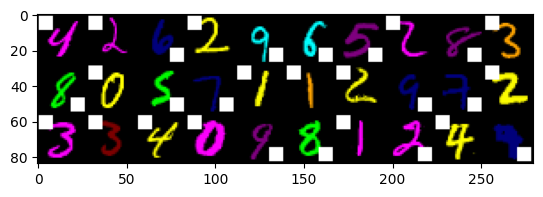

In [10]:
# Show Transet
j=0
case=[]
for i in range(30):
    if j==0:
        let = train[i]
        j +=1
    else:
        let = torch.concat([let, train[i]],dim=2)
        j +=1
    if j%10==0:
        case.append(let)
        j=0
    
imshow(torch.concat(case, dim=1))

## Test Dataset

### Testbed 1 - Total Test Dataset

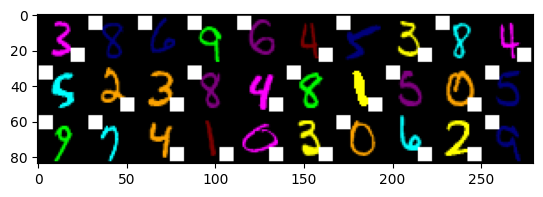

In [11]:
# Show Total Test Dataset
j=0
case=[]
for i in range(30):
    if j==0:
        let = test_tot[i]
        j +=1
    else:
        let = torch.concat([let, test_tot[i]],dim=2)
        j +=1
    if j%10==0:
        case.append(let)
        j=0
    
imshow(torch.concat(case, dim=1))

### Testbed1 - Invariant Test Dataset

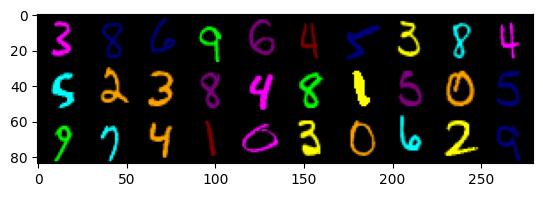

In [12]:
# Show Invariant Test Dataset
j=0
case=[]
for i in range(30):
    if j==0:
        let = test_inv[i]
        j +=1
    else:
        let = torch.concat([let, test_inv[i]],dim=2)
        j +=1
    if j%10==0:
        case.append(let)
        j=0
    
imshow(torch.concat(case, dim=1))

### Testbed2 - Grayscale with Spurious Test Dataset

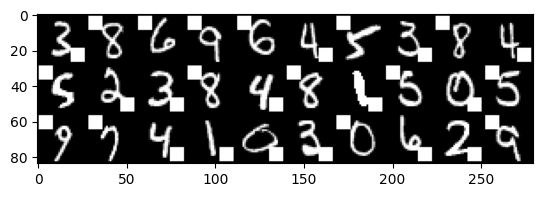

In [13]:
j=0
case=[]
for i in range(30):
    if j==0:
        let = test_spugray[i]
        j +=1
    else:
        let = torch.concat([let, test_spugray_final[i]],dim=2)
        j +=1
    if j%10==0:
        case.append(let)
        j=0
    
imshow(torch.concat(case, dim=1))

### Testbed2 - Grayscale with invariant Test Dataset

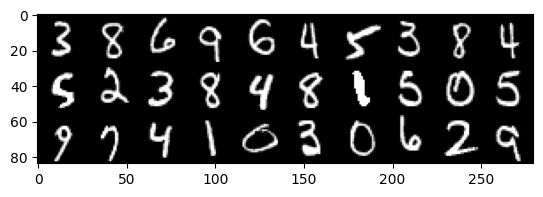

In [14]:
j=0
case=[]
for i in range(30):
    if j==0:
        let = test_gray[i]
        j +=1
    else:
        let = torch.concat([let, test_gray[i]],dim=2)
        j +=1
    if j%10==0:
        case.append(let)
        j=0
    
imshow(torch.concat(case, dim=1))

### Group Distribution

In [15]:
print("Group Distribution in Training Set")
for i in range(4):
    xxx = group_idx==i
    print(f"Group {i}: ",xxx.sum().item())

Group Distribution in Training Set
Group 0:  21814
Group 1:  1128
Group 2:  1121
Group 3:  20937


In [16]:
print("Group Distribution in Validation Set")
for i in range(4):
    xxx = val_group_idx==i
    print(f"Group {i}: ",xxx.sum().item())

Group Distribution in Validation Set
Group 0:  1258
Group 1:  1338
Group 2:  1187
Group 3:  1217


In [17]:
print("Group Distribution in Test Set")
for i in range(4):
    xxx = target_group_idx==i
    print(f"Group {i}: ",xxx.sum().item())

Group Distribution in Test Set
Group 0:  252
Group 1:  4806
Group 2:  4699
Group 3:  243


# Dataset & DataLoader

In [18]:
# Make Grayscale Train Task
reset_torch_seed(flags.seed)
## GrayScale
train_gray_dataset = TensorDataset(train_gray, train_gray_target, group_idx)
train_gray_loader = DataLoader(train_gray_dataset, batch_size=flags.batch_size, shuffle=True)

## Group_known
train_dataset = TensorDataset(train_final, target, group_idx)
train_loader = DataLoader(train_dataset, batch_size=flags.batch_size, shuffle=True)

## Weight Sampler
group_num = (torch.tensor([0,1,2,3]).view(-1,1)==group_idx).sum(1)
group_weight = 1/group_num
weight = group_weight[group_idx.int()]
sampler = WeightedRandomSampler(weight, len(train_dataset), replacement=True)
train_w_loader = DataLoader(train_dataset, batch_size=flags.batch_size, sampler=sampler)

## Val_gray
val_gray_dataset = TensorDataset(val_gray, val_gray_target, val_group_idx)
val_gray_loader = DataLoader(val_gray_dataset,batch_size=flags.batch_size, shuffle=True)
# Make Target Task

## Total
test_tot_dataset = TensorDataset(test_tot, test_tot_target, target_group_idx)
test_tot_loader = DataLoader(test_tot_dataset, batch_size=flags.batch_size, shuffle=False)

## Invariant
test_inv_dataset = TensorDataset(test_inv, test_inv_target, target_group_idx)
test_inv_loader = DataLoader(test_inv_dataset, batch_size=flags.batch_size, shuffle=False)

## spugray
test_spugray_dataset = TensorDataset(test_spugray, test_spugray_target, target_group_idx)
test_spugray_loader = DataLoader(test_spugray_dataset, batch_size=flags.batch_size, shuffle=False)

## GrayScale
test_gray_dataset = TensorDataset(test_gray, test_gray_target, target_group_idx)
test_gray_loader = DataLoader(test_gray_dataset, batch_size=flags.batch_size, shuffle=False)


# Training

# Spurious-train vs GrayScale-Test

In [19]:
def call_resnet():
    reset_torch_seed(flags.seed)
    import torchvision.models as models

    resnet = models.resnet18(pretrained=True)

    resnet.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)

    num_classes = 2  
    resnet.fc = nn.Linear(512, num_classes)
    return resnet

# Setting 
from torch.utils.data import DataLoader, TensorDataset

criterion = torch.nn.CrossEntropyLoss(reduction="none")


In [20]:
def train_erm(train_loader, model, criterion, optimizer):
    reset_torch_seed(flags.seed)
    model.train()
    for ind, batch in enumerate(train_loader):
        optimizer.zero_grad(True)
        x, y, g = batch
        
        x = x.float().cuda()
        y = y.cuda()
        g = g.long().cuda()

        out = model(x)
        loss_ = criterion(out, y)
        loss = loss_.mean()
        loss.backward()
        optimizer.step()

In [21]:
def train_spurious(train_loader, model, criterion, optimizer):
    model.eval()
    for ind, batch in enumerate(train_loader):
        optimizer.zero_grad(True)
        x, y, g = batch
        with torch.no_grad():
            x = x.float().cuda()
            y = y.cuda()
            g = g.long().cuda()
        
            out = model(x)
            
        loss_ = criterion(out, y)
        loss = loss_.mean()
        loss.backward()
        optimizer.step()

In [22]:
def train_gdro(train_loader, model, criterion, optimizer):
    reset_torch_seed(flags.seed)
    group = torch.arange(4).cuda()
    model.train()
    adv_probs = flags.adv
    adv_probs = adv_probs.cuda()
    for ind, batch in enumerate(train_loader):
        optimizer.zero_grad(True)
        x, y, g = batch
        
        x = x.float().cuda()
        y = y.cuda()
        g = g.long().cuda()

        out = model(x)
        loss_ = criterion(out, y)
        group_map = (group.view(-1,1)==g).float()
        group_loss = torch.matmul(group_map, loss_)
        adv_probs = adv_probs*torch.exp(flags.robust_step*group_loss)
        adv_probs = adv_probs/adv_probs.sum()
        loss = torch.dot(group_loss, adv_probs)
        loss.backward()
        optimizer.step()
        adv_probs=adv_probs.detach()
        
    flags.adv = adv_probs

In [23]:
def train_asam(train_loader, model, criterion, optimizer):
    reset_torch_seed(flags.seed)
    model.train()
    for ind, batch in enumerate(train_loader):
        # First Step
        enable_running_stats(model)
        x, y, g = batch
        
        x = x.float().cuda()
        y = y.cuda()
        g = g.long().cuda()

        out = model(x)
        loss_ = criterion(out, y)
        loss = loss_.mean()
        loss.backward()
        optimizer.first_step(zero_grad=True)
        
        # Second Step
        disable_running_stats(model)
        out = model(x)
        loss_ = criterion(out, y)
        loss = loss_.mean()
        loss.backward()
        optimizer.second_step(zero_grad=True)

In [24]:
def train_asgdro(train_loader, model, criterion, optimizer):
    reset_torch_seed(flags.seed)
    model.train()
    adv_probs = flags.adv
    adv_probs = adv_probs.cuda()
    for ind, batch in enumerate(train_loader):
        # First Step
        enable_running_stats(model)
        x, y, g = batch
        
        x = x.float().cuda()
        y = y.cuda()
        g = g.long().cuda()

        out = model(x)
        loss_ = criterion(out, y)
        loss = loss_.mean()
        loss.backward()
        optimizer.first_step(zero_grad=True)
        
        # Second Step
        disable_running_stats(model)
        out = model(x)
        loss_ = criterion(out, y)
        group_map = (group.view(-1,1)==g).float()
        group_loss = torch.matmul(group_map, loss_)
        adv_probs = adv_probs*torch.exp(flags.robust_step*group_loss)
        adv_probs = adv_probs/adv_probs.sum()
        loss = torch.dot(group_loss, adv_probs)
        loss.backward()
        adv_probs=adv_probs.detach()
        optimizer.second_step(zero_grad=True)
        
    flags.adv = adv_probs

In [25]:
def val_gray_task(best_acc, loader, model):
    reset_torch_seed(flags.seed)
    group = torch.arange(4)
    model.eval()
    acc = 0
    for ind, batch in enumerate(loader):
        x, y, g = batch
        x = x.float().cuda()
        y = y.cuda()
        out = model(x)
        y_pred = torch.argmax(out, dim=1)
        #group_map = (group.view(-1,1)==g).float()
        acc += (y_pred==y).sum()
    final_acc = acc/len(loader.dataset)*100
    print(f"Val_Gray {epoch}: ", final_acc.item())
    if best_acc < final_acc:
        print("=================")
        print("=================")
        print("=======BEST======")
        print("=================")
        print("=================")
        flags.best_acc = final_acc

In [26]:
def test_task(loader, model):
    reset_torch_seed(flags.seed)
    model.eval()
    acc = 0
    for ind, batch in enumerate(loader):
        x, y, g = batch
        x = x.float().cuda()
        y = y.cuda()
        out = model(x)
        y_pred = torch.argmax(out, dim=1)
        acc += (y_pred==y).sum()
    final_acc = acc/len(loader.dataset)*100
    print(f"Epoch {epoch}: ", final_acc.item())

# ERM

In [ ]:
# ERM
for weight_decay in [1]:#[1, 0.1, 1e-3,1e-4]:
    for lr in [1e-3]:#[1e-3, 1e-4]:
        print("+++++++++++++++++++++++++++++++++++++++++")
        print("============================")
        print(f"lr_{lr} // wd_{weight_decay}")
        print("============================")
        flags.best_acc = 0
        model = call_resnet().cuda()
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
        group = torch.tensor([0,1,2,3]).cuda()
        # Spurious-train == GrayScale-Test
        for epoch in range(20):#range(flags.epoch):
            print("="*5, epoch, "="*5)
            train_erm(train_loader, model, criterion, optimizer)
            print(f"===Epoch {epoch} Finished===")
            print(f"Gray Validation")
            val_gray_task(flags.best_acc, val_gray_loader, model)            
            print("Spurisou&Color&Shape")
            test_task(test_tot_loader, model)
            print("Color&Shape")
            test_task(test_inv_loader, model)
            print("SpuGray")
            test_task(test_spugray_loader, model)
            print("Grayscale")
            test_task(test_gray_loader, model)
        print("+++++++++++++++++++++++++++++++++++++++++")


    

# ASAM

In [28]:
# ASAM

for weight_decay in [1]:#[1, 0.1, 1e-3,1e-4]:
    for lr in [1e-3]:#[1e-3, 1e-4]:
        for rho in [0.05]:#[0.05, 0.2, 0.5, 0.8,]:
            print("+++++++++++++++++++++++++++++++++++++++++")
            print("============================")
            print(f"lr_{lr} // wd_{weight_decay} // rho_{rho}")
            print("============================")
            flags.best_acc=0
            model = call_resnet().cuda()
            base_optimizer = optim.SGD
            optimizer = SAM(model.parameters(), base_optimizer, lr=lr, weight_decay=weight_decay, rho=rho, adaptive=True)

            group = torch.tensor([0,1,2,3]).cuda()
            flags.adv = torch.ones(4)/4
            flags.robust_step = 0.01
            for epoch in range(20):#range(flags.epoch):
                print("="*5, epoch, "="*5)
                train_asam(train_loader, model, criterion, optimizer)
                print(f"===Epoch {epoch} Finished===")
                print(f"Gray Validation")
                val_gray_task(flags.best_acc, val_gray_loader, model)            
                print("Spurisou&Color&Shape")
                test_task(test_tot_loader, model)
                print("Color&Shape")
                test_task(test_inv_loader, model)
                print("SpuGray")
                test_task(test_spugray_loader, model)
                print("Grayscale")
                test_task(test_gray_loader, model)
            print("+++++++++++++++++++++++++++++++++++++++++")

+++++++++++++++++++++++++++++++++++++++++
lr_0.001 // wd_1 // rho_0.05
===== 0 =====
===Epoch 0 Finished===
Gray Validation
Val_Gray 0:  54.380001068115234
=======BEST======
Spurisou&Color&Shape
Epoch 0:  92.64999389648438
Color&Shape
Epoch 0:  89.7699966430664
SpuGray
Epoch 0:  39.040000915527344
Grayscale
Epoch 0:  52.70000076293945
===== 1 =====
===Epoch 1 Finished===
Gray Validation
Val_Gray 1:  52.81999588012695
Spurisou&Color&Shape
Epoch 1:  99.2699966430664
Color&Shape
Epoch 1:  97.9699935913086
SpuGray
Epoch 1:  46.689998626708984
Grayscale
Epoch 1:  51.16999816894531
===== 2 =====
===Epoch 2 Finished===
Gray Validation
Val_Gray 2:  52.23999786376953
Spurisou&Color&Shape
Epoch 2:  99.85999298095703
Color&Shape
Epoch 2:  99.37999725341797
SpuGray
Epoch 2:  49.56999969482422
Grayscale
Epoch 2:  50.72999572753906
===== 3 =====
===Epoch 3 Finished===
Gray Validation
Val_Gray 3:  52.119998931884766
Spurisou&Color&Shape
Epoch 3:  99.88999938964844
Color&Shape
Epoch 3:  99.76999664306

# GDRO

In [29]:
# GDRO
for weight_decay in [1]:#[1, 0.1, 1e-3,1e-4]:
    for lr in [1e-3]:#:[1e-3, 1e-4]:
        print("+++++++++++++++++++++++++++++++++++++++++")
        print("============================")
        print(f"lr_{lr} // wd_{weight_decay}")
        print("============================")
        flags.best_acc = 0
        model = call_resnet().cuda()
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
        group = torch.tensor([0,1,2,3]).cuda()
        flags.adv = torch.ones(4)/4
        flags.robust_step = 0.01
        for epoch in range(20):#range(flags.epoch):
            print("="*5, epoch, "="*5)
            train_gdro(train_w_loader, model, criterion, optimizer)
            print(f"===Epoch {epoch} Finished===")
            print(f"Gray Validation")
            val_gray_task(flags.best_acc, val_gray_loader, model)            
            print("Spurisou&Color&Shape")
            test_task(test_tot_loader, model)
            print("Color&Shape")
            test_task(test_inv_loader, model)
            print("SpuGray")
            test_task(test_spugray_loader, model)
            print("Grayscale")
            test_task(test_gray_loader, model)
        print("+++++++++++++++++++++++++++++++++++++++++")

+++++++++++++++++++++++++++++++++++++++++
lr_0.001 // wd_1
===== 0 =====
===Epoch 0 Finished===
Gray Validation
Val_Gray 0:  52.119998931884766
=======BEST======
Spurisou&Color&Shape
Epoch 0:  99.9699935913086
Color&Shape
Epoch 0:  99.91999816894531
SpuGray
Epoch 0:  50.44000244140625
Grayscale
Epoch 0:  51.089996337890625
===== 1 =====
===Epoch 1 Finished===
Gray Validation
Val_Gray 1:  52.23999786376953
=======BEST======
Spurisou&Color&Shape
Epoch 1:  99.9699935913086
Color&Shape
Epoch 1:  99.94999694824219
SpuGray
Epoch 1:  50.30999755859375
Grayscale
Epoch 1:  51.01000213623047
===== 2 =====
===Epoch 2 Finished===
Gray Validation
Val_Gray 2:  51.959999084472656
Spurisou&Color&Shape
Epoch 2:  100.0
Color&Shape
Epoch 2:  99.98999786376953
SpuGray
Epoch 2:  50.56999969482422
Grayscale
Epoch 2:  50.56999969482422
===== 3 =====
===Epoch 3 Finished===
Gray Validation
Val_Gray 3:  48.380001068115234
Spurisou&Color&Shape
Epoch 3:  99.72999572753906
Color&Shape
Epoch 3:  99.67999267578125
S

# ASGDRO

In [30]:
# ASGDRO
for weight_decay in [1]:#[1, 0.1, 1e-3,1e-4]:
    for lr in [1e-3]:#[1e-3, 1e-4]:
        for rho in [0.8]:#[0.05, 0.2, 0.5, 0.8]:
            print("+++++++++++++++++++++++++++++++++++++++++")
            print("============================")
            print(f"lr_{lr} // wd_{weight_decay} // rho_{rho}")
            print("============================")
            flags.best_acc=0
            model = call_resnet().cuda()
            base_optimizer = optim.SGD
            optimizer = SAM(model.parameters(), base_optimizer, lr=lr, weight_decay=weight_decay, rho=rho, adaptive=True)
            group = torch.tensor([0,1,2,3]).cuda()
            flags.adv = torch.ones(4)/4
            flags.robust_step = 0.01
            for epoch in range(20):#range(flags.epoch):
                print("="*5, epoch, "="*5)
                train_asgdro(train_w_loader, model, criterion, optimizer)
                print(f"===Epoch {epoch} Finished===")
                print(f"Gray Validation")
                val_gray_task(flags.best_acc, val_gray_loader, model)            
                print("Spurisou&Color&Shape")
                test_task(test_tot_loader, model)
                print("Color&Shape")
                test_task(test_inv_loader, model)
                print("SpuGray")
                test_task(test_spugray_loader, model)
                print("Grayscale")
                test_task(test_gray_loader, model)
            print("+++++++++++++++++++++++++++++++++++++++++")


+++++++++++++++++++++++++++++++++++++++++
lr_0.001 // wd_1 // rho_0.8
===== 0 =====
===Epoch 0 Finished===
Gray Validation
Val_Gray 0:  53.42000198364258
=======BEST======
Spurisou&Color&Shape
Epoch 0:  99.94999694824219
Color&Shape
Epoch 0:  99.89999389648438
SpuGray
Epoch 0:  50.62000274658203
Grayscale
Epoch 0:  53.02000045776367
===== 1 =====
===Epoch 1 Finished===
Gray Validation
Val_Gray 1:  52.31999588012695
Spurisou&Color&Shape
Epoch 1:  99.95999908447266
Color&Shape
Epoch 1:  99.93000030517578
SpuGray
Epoch 1:  50.519996643066406
Grayscale
Epoch 1:  52.2599983215332
===== 2 =====
===Epoch 2 Finished===
Gray Validation
Val_Gray 2:  52.0
Spurisou&Color&Shape
Epoch 2:  99.98999786376953
Color&Shape
Epoch 2:  99.94999694824219
SpuGray
Epoch 2:  50.599998474121094
Grayscale
Epoch 2:  50.779998779296875
===== 3 =====
===Epoch 3 Finished===
Gray Validation
Val_Gray 3:  52.619998931884766
Spurisou&Color&Shape
Epoch 3:  99.9699935913086
Color&Shape
Epoch 3:  99.9699935913086
SpuGray
Ep